# Credit Card Customer Segmention - Cleaning Stage

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Reading dataset
credit_card_ds = pd.read_csv(r"..\..\Data_Scientist_Training\credit-card-customer-segmentation\datasets\Credit Card Customer Data.csv")
credit_card_ds.head(5)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [3]:
# Learning more about the columns
credit_card_ds.columns

Index(['Sl_No', 'Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards',
       'Total_visits_bank', 'Total_visits_online', 'Total_calls_made'],
      dtype='str')

### Checking out statistical and distribution information about our dataset

In [4]:
"""
Getting information about data types and null values where we can confirmt that
there are no missing in our dataset
"""

credit_card_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [5]:
# Getting a statistical distribution from each column
credit_card_ds.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [6]:
# Watching shape of our dataset
credit_card_ds.shape

(660, 7)

As we can see above, our dataset has a shape of 660 rows with 7 columns. Additionally, we obtained a statistical distribution where we can see some highlights such as:

- The average credit limit could have some outliers as max value is 200000 and minimum value 3000
- The distribution of the total distributed banks looks good as the means are around 2.60 with a standard deviation of 1.63. 
- On the other hand, the remaining columns look great but they could have outliers as their maximum values are huge compared with their standard deviation and mean which are around 2-3.

## Beginning Cleaning Stage

In [7]:
# Reviewing first 5 rows of our DF
credit_card_ds.head(5)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [8]:
# Checking data types
credit_card_ds.dtypes

Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: object

In [9]:
# Changing column names
credit_card_ds = credit_card_ds.rename(columns = {
    "Sl_No":"Serial_Number",
    "Customer Key": "Customer_Key"
    }
)

credit_card_ds.columns

Index(['Serial_Number', 'Customer_Key', 'Avg_Credit_Limit',
       'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online',
       'Total_calls_made'],
      dtype='str')

First, we rename the first two columns to avoid issues with spaces in column names and provide a clearer understanding of what each column represents.

In [10]:
# Checking for duplicate rows
credit_card_ds[credit_card_ds.duplicated(keep = False)]

,Serial_Number,Customer_Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made


In [11]:
# Validating unique customer keys
credit_card_ds["Customer_Key"].value_counts()

Customer_Key
47437    2
37252    2
97935    2
96929    2
50706    2
        ..
51108    1
60732    1
53834    1
80655    1
80150    1
Name: count, Length: 655, dtype: int64

In [12]:
# Validating repeated serial number
credit_card_ds["Serial_Number"].value_counts()

Serial_Number
1      1
2      1
3      1
4      1
5      1
      ..
656    1
657    1
658    1
659    1
660    1
Name: count, Length: 660, dtype: int64

Subsequently, we ensure that the dataset does not contain duplicate records by checking for repeated values, particularly in the serial numbers and customer keys.

Last but not least, we identified repeated customer keys, which could potentially affect the accuracy of our statistical analysis.

### Dealing with outliers

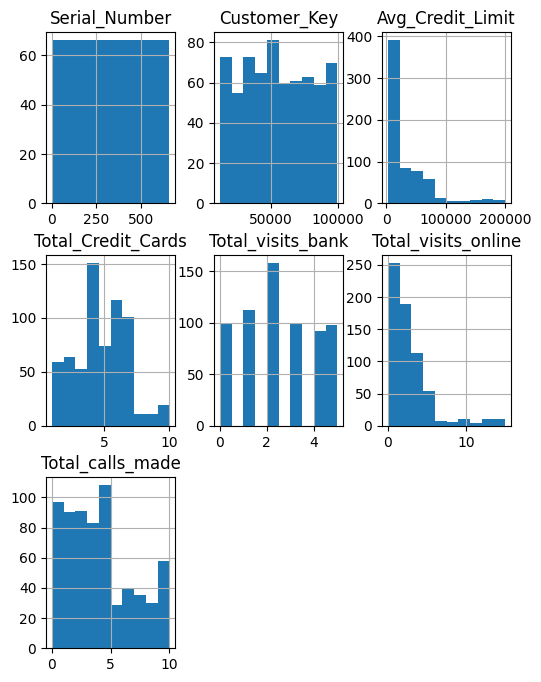

In [13]:
# Plotting some histograms to get a better overview of outliers
credit_card_ds.hist(figsize = (6, 8));

Based on the histograms plotted previously, the **serial number** presents a discrete distribution, as its values are limited to a specific range from 1 to 5. Since this variable represents an identifier rather than a meaningful customer characteristic, it will not provide useful information for customer segmentation.

On the other hand, **Average Credit Limit** and **Total Visits Online** show right-skewed distributions. This indicates that the mean is likely higher than the median. These distributions may also contain potential outliers, which will be investigated further. When summarizing these variables, the **median** can be a more robust measure of central tendency because it is less sensitive to extreme values.

Finally, **Customer Key**, **Total Calls Made**, and **Total Credit Cards** appear to have distributions that are closer to a normal or symmetric shape. However, further analysis will be performed to identify potential outliers, unusual observations, and other data-quality issues before proceeding with the clustering process.

#### Reviewing Average Credit and Total Visits fields

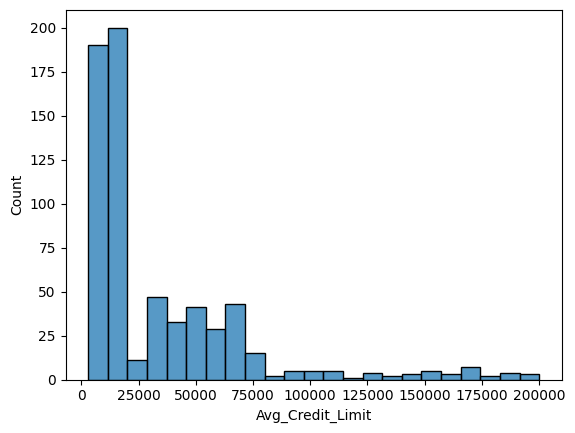

In [ ]:
# Getting more overview on the Average Credit histogram
sns.histplot(credit_card_ds["Avg_Credit_Limit"]);

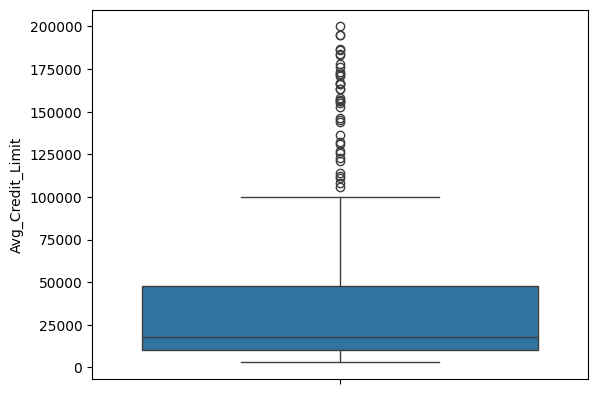

In [15]:
# Plotting box plot for Average Credit Limit
sns.boxplot(credit_card_ds["Avg_Credit_Limit"]);

In [ ]:
# Getting total amount of credits that are above 150000
credit_card_ds[credit_card_ds["Avg_Credit_Limit"] >= 150000].shape

(24, 7)

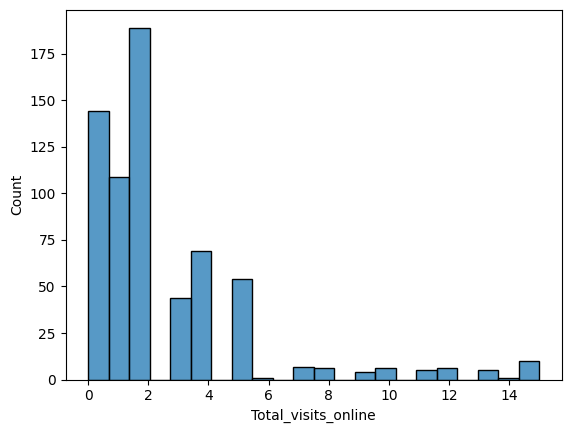

In [21]:
# Getting more overview on the Total Visits Online histogram
sns.histplot(credit_card_ds["Total_visits_online"]);

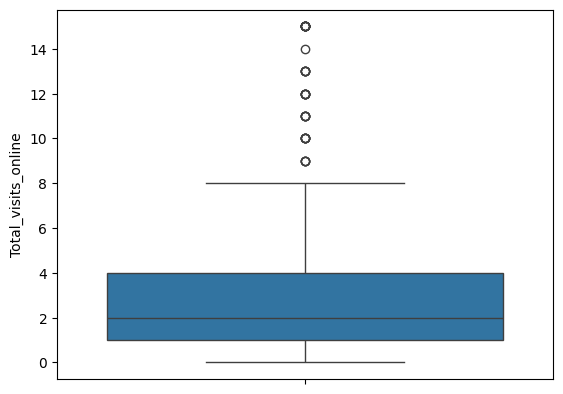

In [22]:
# Plotting box plot for Total Visits Online
sns.boxplot(credit_card_ds["Total_visits_online"]);

In [23]:
# Getting total amount of credits that are above 8
credit_card_ds[credit_card_ds["Total_visits_online"] > 8].shape

(37, 7)